In [2]:
## Exploring summary stats to think about best ways to visuallize and compare data sets

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
mdibl_df = pd.read_csv("../IFCBData/summaries/mdiblsum.csv")
nauset_df = pd.read_csv("../IFCBData/summaries/nausetSum.csv")
harpswell_df = pd.read_csv("../IFCBData/summaries/harpswell.csv")
mvco_df = pd.read_csv("../IFCBData/summaries/mvco_summary.csv")

In [6]:
df_map = {
    "mdibl": mdibl_df,
    "nauset": nauset_df,
    "harpswell": harpswell_df,
    "mvco": mvco_df,
}

processed_df_map = {}

In [20]:
for name, df in df_map.items():
    # Split PID into datetime and IFCB source fields.
    split_cols = df["pid"].str.split("_", expand=True)

    df = df.copy()
    df["datetime_str"] = split_cols[0]
    df["ifcb"] = split_cols[1]
    df["datetime"] = pd.to_datetime(
        df["datetime_str"].str[1:],
        format="%Y%m%dT%H%M%S",
        errors="coerce",
    )

    df = df.dropna(subset=["datetime"]).sort_values("datetime")
    processed_df_map[name] = df

# Keep one default df for later single-dataset exploration cells.
df = processed_df_map["nauset"]

In [21]:
for name, df in processed_df_map.items():
    print(f"\n{name}: {len(df)} rows")
    print(df[["pid", "datetime", "ifcb"]].head(2))

print("\nActive df for downstream cells: nauset")


mdibl: 1123 rows
                        pid            datetime     ifcb
0  D20210818T162700_IFCB152 2021-08-18 16:27:00  IFCB152
1  D20210818T200600_IFCB152 2021-08-18 20:06:00  IFCB152

nauset: 453 rows
                        pid            datetime     ifcb
0  D20250501T170646_IFCB145 2025-05-01 17:06:46  IFCB145
1  D20250501T200837_IFCB145 2025-05-01 20:08:37  IFCB145

harpswell: 2332 rows
                        pid            datetime     ifcb
0  D20240506T182949_IFCB125 2024-05-06 18:29:49  IFCB125
1  D20240507T001725_IFCB125 2024-05-07 00:17:25  IFCB125

mvco: 100 rows
                        pid            datetime     ifcb
0  D20191001T001056_IFCB010 2019-10-01 00:10:56  IFCB010
1  D20191001T060059_IFCB010 2019-10-01 06:00:59  IFCB010

Active df for downstream cells: nauset


In [22]:
## Calculate inhibit/look ratio across all processed datasets
for name, df in processed_df_map.items():
    df = df.copy()
    df["inhibittime_final"] = pd.to_numeric(df["inhibittime_final"], errors="coerce")
    df["looktime"] = pd.to_numeric(df["looktime"], errors="coerce")
    df["inhibitRatio"] = df["inhibittime_final"] / df["looktime"]
    processed_df_map[name] = df

In [19]:
for name, df in processed_df_map.items():
    has_col = "inhibitRatio" in df.columns
    valid_n = df["inhibitRatio"].notna().sum() if has_col else 0
    print(f"{name}: inhibitRatio column={has_col}, non-null values={valid_n}")

mdibl: inhibitRatio column=True, non-null values=1123
nauset: inhibitRatio column=True, non-null values=453
harpswell: inhibitRatio column=True, non-null values=2331
mvco: inhibitRatio column=True, non-null values=100


In [25]:
# Filter out values above the 99th percentile of inhibitRatio for each dataset.
filtered_df_map = {}
filter_report_rows = []

for name, df in processed_df_map.items():
    upper = df["inhibitRatio"].quantile(0.99)
    mask = df["inhibitRatio"] <= upper

    filtered_df_map[name] = df.loc[mask].copy()

    n_before = len(df)
    n_after = len(filtered_df_map[name])
    n_filtered = n_before - n_after

    filter_report_rows.append(
        {
            "dataset": name,
            "p99_threshold": upper,
            "n_before": n_before,
            "n_after": n_after,
            "n_filtered": n_filtered,
            "pct_filtered": (n_filtered / n_before * 100.0) if n_before else 0.0,
        }
    )

filter_report_df = pd.DataFrame(filter_report_rows).sort_values("dataset")
print(filter_report_df.to_string(index=False))

# Keep a default filtered df for downstream single-dataset plotting cells.
df_filtered = filtered_df_map["nauset"]

  dataset  p99_threshold  n_before  n_after  n_filtered  pct_filtered
harpswell       1.215431      2332     2307          25      1.072041
    mdibl       7.395780      1123     1111          12      1.068566
     mvco       2.169877       100       99           1      1.000000
   nauset       5.290860       453      448           5      1.103753


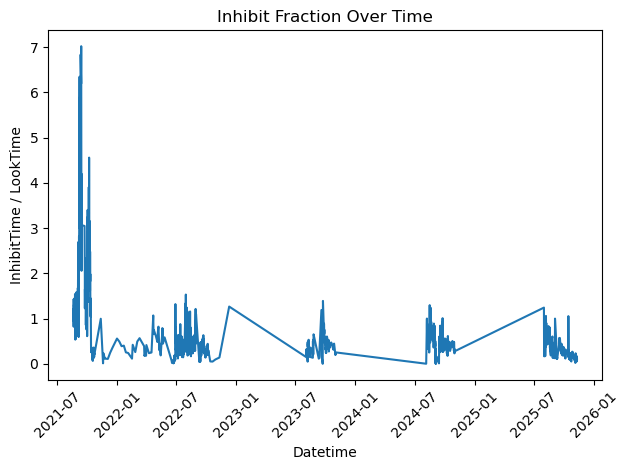

In [26]:
plt.figure()
plt.plot(filtered_df_map["mdibl"]["datetime"], filtered_df_map["mdibl"]["inhibitRatio"])
plt.xlabel("Datetime")
plt.ylabel("InhibitTime / LookTime")
plt.title("Inhibit Fraction Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/l8/3r0hwyy91wg_66xlwdssv2yr0000gn/T/ipykernel_75169/2627009712.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=dataset_names, showfliers=False)


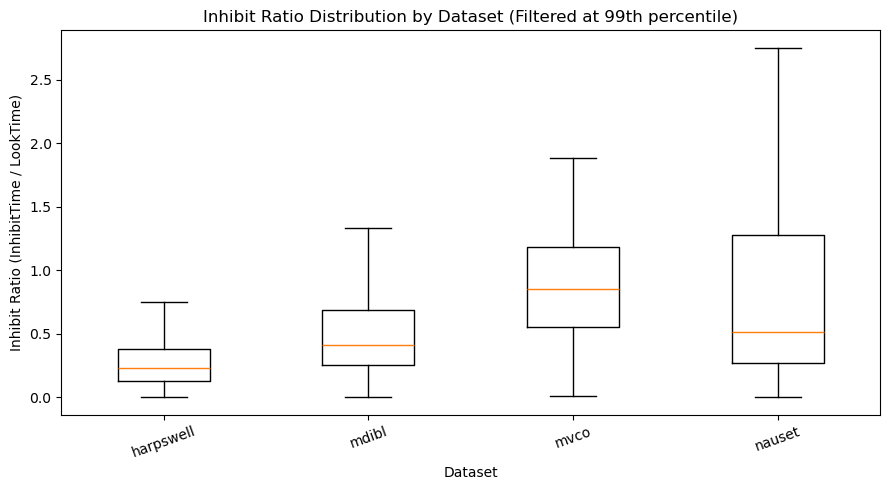

In [29]:
dataset_names = sorted(filtered_df_map.keys())
box_data = [filtered_df_map[name]["inhibitRatio"].dropna().values for name in dataset_names]

plt.figure(figsize=(9, 5))
plt.boxplot(box_data, labels=dataset_names, showfliers=False)
plt.ylabel("Inhibit Ratio (InhibitTime / LookTime)")
plt.xlabel("Dataset")
plt.title("Inhibit Ratio Distribution by Dataset (Filtered at 99th percentile)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

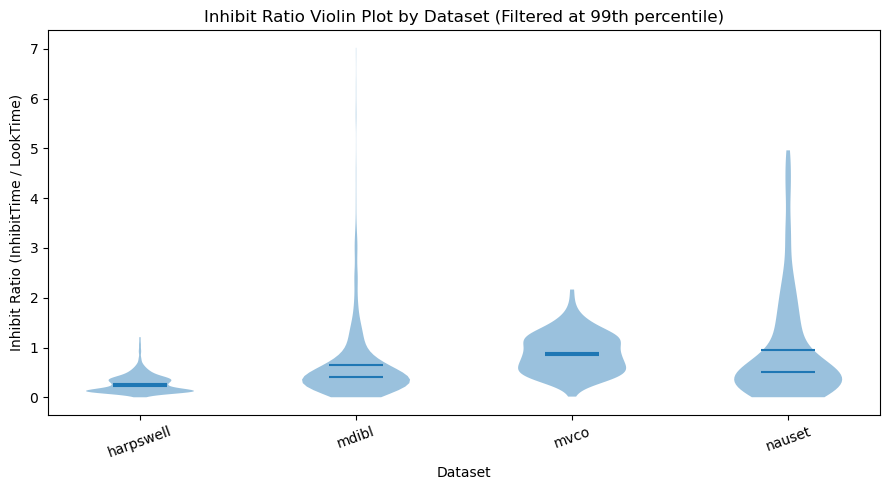

In [30]:
dataset_names = sorted(filtered_df_map.keys())
violin_data = [filtered_df_map[name]["inhibitRatio"].dropna().values for name in dataset_names]

plt.figure(figsize=(9, 5))
parts = plt.violinplot(violin_data, showmeans=True, showmedians=True, showextrema=False)

for body in parts["bodies"]:
    body.set_alpha(0.45)

plt.xticks(range(1, len(dataset_names) + 1), dataset_names, rotation=20)
plt.ylabel("Inhibit Ratio (InhibitTime / LookTime)")
plt.xlabel("Dataset")
plt.title("Inhibit Ratio Violin Plot by Dataset (Filtered at 99th percentile)")
plt.tight_layout()
plt.show()

In [ ]:
## next step is to do this for some data from  mvco and maybe a cruise and just put them all on the same plot to compare

In [72]:

### Thinking about rois 
df_filtered.describe()


,roi0,roi1,roi2,roi3,roi4,roi5,roi6,roi7,vfinal,inhibittime_final,looktime,datetime,inhibitRatio
count,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111.000000,1111,1111.000000
mean,148.253825,4229.180018,237.578758,17.724572,7.168317,6.170117,5.254725,4.334833,3.341010,379.172909,801.842512,2023-06-17 01:59:44.740774144,0.652695
min,0.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.055793,0.652363,13.390230,2021-08-18 16:27:00,0.000551
25%,3.000000,2618.500000,92.000000,3.000000,0.000000,0.000000,0.000000,0.000000,2.836848,234.234748,680.843594,2022-06-23 17:13:08,0.250998
50%,15.000000,3770.000000,178.000000,6.000000,0.000000,0.000000,0.000000,0.000000,3.481975,339.265382,835.674028,2022-09-17 14:17:28,0.411564
75%,85.500000,5373.000000,333.000000,15.000000,0.000000,0.000000,0.000000,0.000000,3.980936,484.622049,955.424609,2024-09-25 18:56:14,0.690280
max,3621.000000,12285.000000,3196.000000,2418.000000,3828.000000,4165.000000,3258.000000,2527.000000,4.989134,1050.961667,1197.392194,2025-11-11 02:23:23,7.022472
std,454.571586,2464.274907,233.177307,108.833296,124.104168,135.284415,118.768390,100.447797,0.904017,213.148199,216.964067,NaN,0.812822


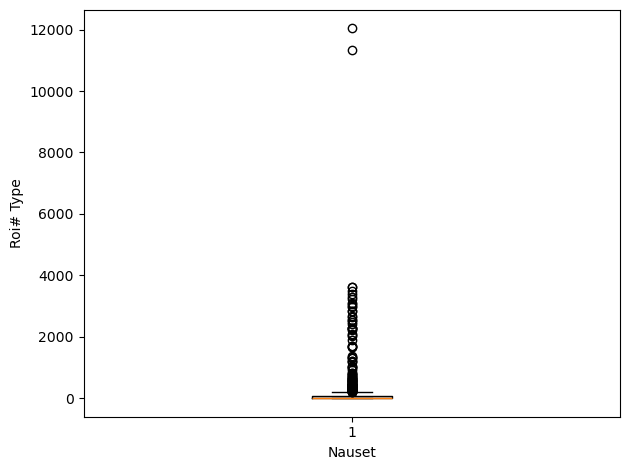

In [99]:
plt.figure()
plt.boxplot(fildf["roi0"])
plt.xlabel("Nauset")
plt.ylabel("Roi# Type")
#plt.xlim(1000)
# Jittered scatter
# x = np.random.normal(1, 0.04, size=len(df_filtered["roi7"]))  # center at 1, small spread
# plt.scatter(x, df_filtered["roi7"], alpha=0.5)
plt.tight_layout()
plt.show()

In [87]:
print(df["roi5"].quantile(.99))
print(df["roi6"].quantile(.99))
print(df["roi7"].quantile(.99))


8.899999999999864
4.679999999999836
0.0


In [88]:
filt = df["roi5"].quantile(.99)
fildf = df[df["roi5"] <= filt]

In [91]:
print(fildf["roi6"].max())

6


In [62]:
df = df.sort_values("roi5")
print(df.tail(n=10))

     roi0   roi1  roi2   roi3  roi4  roi5  roi6  roi7    vfinal  \
148   982  10342  1076     84     8    10     0     0  0.858384   
231   106    406    68     57     8    15     0     0  4.813580   
364  2113   3483  2314    690   112    15     0     0  2.749565   
167     0      0     8    345   232    30     0     0  4.943602   
145   223   8916  1806    327    96    40     0     0  1.451332   
363   618   7967  1874    540   236    75    60    14  1.449065   
329   696    542   552    252   164   100    72    42  0.394383   
166     2     10   340  26586  8032   480     0     0  1.098581   
226    39    395   376    459   664   665   528   350  4.564845   
222   178   1000   802   1008  1148  1240   900   595  4.033311   

     inhibittime_final     looktime                       pid  \
148         995.647361   206.012083  D20250625T201225_IFCB144   
231          47.453364  1155.259136  D20250721T020437_IFCB145   
364         612.206181   591.020347  D20260122T214559_IFCB144   
16